## Generate thesis figures - RQ1


Generate all figures for the thesis from the model training results. The following figures are generated:
- Training & validation loss per model
- Validation F1 over epochs
- Validation AUC over epochs
- Val vs xBD test results table
- F1/Precision/Recall vs threshold
- ROC curves on xBD test set
-F1 and Recall per damage severity
- Confusion matrices per model

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc

%matplotlib inline

***0. Paths & configuration***

In [2]:
BASE = Path(r"C:\Users\zanca\OneDrive\Desktop\Vrij Unversiteit\extra_year\Thesis\Rapid Assessment of Earthquake Building Damage")

HISTORY_PATHS = {
    "A": BASE / "2_models_trainings" / "model_A" / "outputs" / "history.json",
    "B": BASE / "2_models_trainings" / "model_B" / "outputs" / "history.json",
    "C": BASE / "2_models_trainings" / "model_C" / "outputs" / "history.json",
}
EVAL_PATHS = {
    "A": BASE / "3_experiments" / "model_A" / "evaluation_xbd.json",
    "B": BASE / "3_experiments" / "model_B" / "evaluation_xbd.json",
    "C": BASE / "3_experiments" / "model_C" / "evaluation_xbd.json",
}
FIGURES_DIR = BASE / "3_experiments" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"A": "#534AB7", "B": "#0F6E56", "C": "#993C1D"}
LABELS = {
    "A": "Model A \u2014 End-to-end",
    "B": "Model B \u2014 Human-guided",
    "C": "Model C \u2014 Physics-guided",
}
SEVERITY_COLORS = {
    "minor-damage": "#F4A261",
    "major-damage": "#E76F51",
    "destroyed":    "#9B2226",
}
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

print(f"Figures will be saved to: {FIGURES_DIR}")

Figures will be saved to: C:\Users\zanca\OneDrive\Desktop\Vrij Unversiteit\extra_year\Thesis\Rapid Assessment of Earthquake Building Damage\3_experiments\figures


***1. Load training histories and evaluation results***

In [3]:
def load_history(path: Path) -> dict:
    with open(path) as f:
        h = json.load(f)

    if isinstance(h, list):
        entries     = h
        n_stages    = 1
        stage_sizes = [len(h)]
    else:
        entries     = []
        stage_sizes = []
        for stage_key in sorted(h.keys()):
            entries.extend(h[stage_key])
            stage_sizes.append(len(h[stage_key]))
        n_stages = len(h)

    epochs = list(range(1, len(entries) + 1))
    return {
        "epochs":      epochs,
        "train_loss":  [e["train"]["loss"] for e in entries],
        "val_loss":    [e["val"]["loss"]   for e in entries],
        "train_f1":    [e["train"]["f1"]   for e in entries],
        "val_f1":      [e["val"]["f1"]     for e in entries],
        "val_auc":     [e["val"].get("auc", float("nan")) for e in entries],
        "n_stages":    n_stages,
        "stage_sizes": stage_sizes,
    }


def load_eval(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)


histories, evaluations = {}, {}

for m, p in HISTORY_PATHS.items():
    if p.exists():
        histories[m] = load_history(p)
        print(f"  History loaded:    Model {m} ({len(histories[m]['epochs'])} epochs)")
    else:
        print(f"  WARNING: history not found for Model {m}")

for m, p in EVAL_PATHS.items():
    if p.exists():
        evaluations[m] = load_eval(p)
        print(f"  Evaluation loaded: Model {m}")
    else:
        print(f"  WARNING: evaluation not found for Model {m} — run evaluate_{m}.py first")

  History loaded:    Model A (30 epochs)
  History loaded:    Model B (30 epochs)
  History loaded:    Model C (30 epochs)
  Evaluation loaded: Model A
  Evaluation loaded: Model B
  Evaluation loaded: Model C


***2. Figure 1 — Training and validation loss***

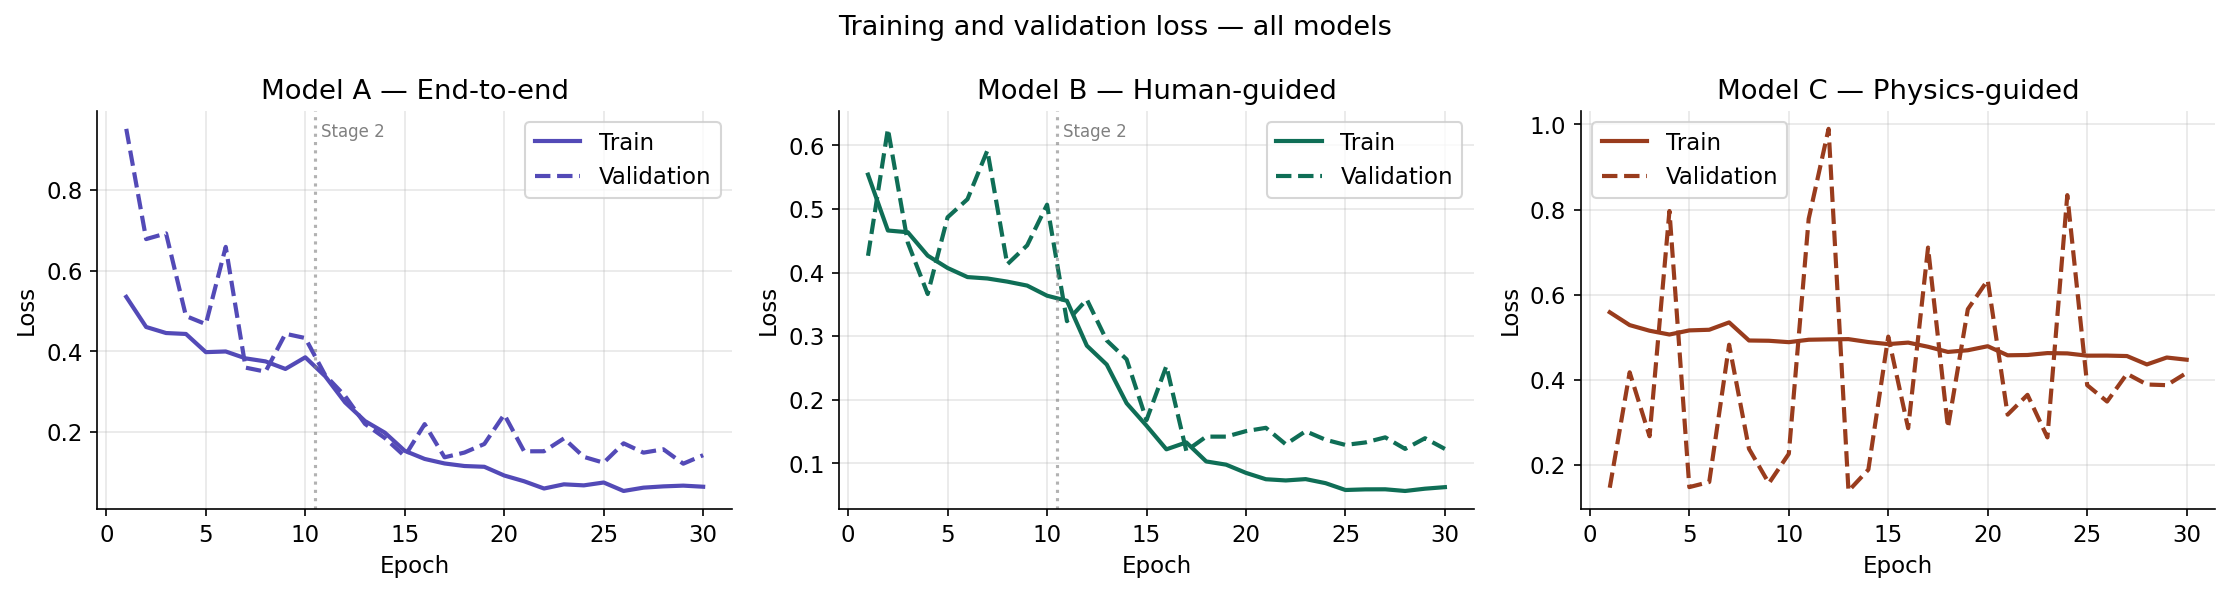

Saved: fig1_loss_curves.png


In [4]:
def plot_loss_curves(histories):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    for ax, (model_id, h) in zip(axes, histories.items()):
        ax.plot(h["epochs"], h["train_loss"],
                label="Train", color=COLORS[model_id], linewidth=2)
        ax.plot(h["epochs"], h["val_loss"],
                label="Validation", color=COLORS[model_id],
                linewidth=2, linestyle="--")
        ax.set_title(LABELS[model_id])
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        if model_id in ("A", "B") and h["n_stages"] == 2:
            boundary = h["stage_sizes"][0] + 0.5
            ax.axvline(x=boundary, color="gray", linestyle=":", alpha=0.6)
            ax.text(boundary + 0.3, ax.get_ylim()[1] * 0.97,
                    "Stage 2", fontsize=8, color="gray", va="top")
    fig.suptitle("Training and validation loss \u2014 all models", fontsize=13)
    fig.tight_layout()
    path = FIGURES_DIR / "fig1_loss_curves.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if histories:
    plot_loss_curves(histories)

***3. Figure 2 — Validation F1 over epochs***

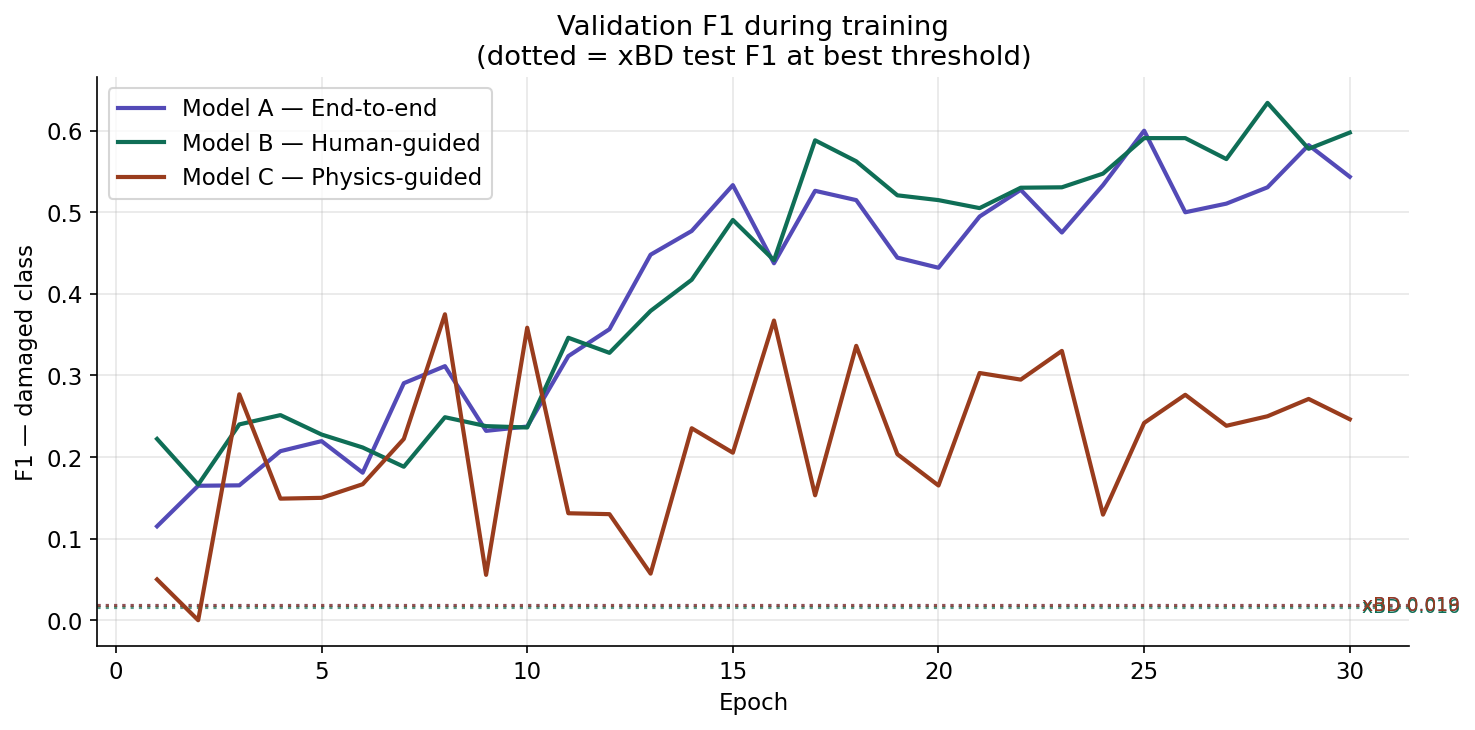

Saved: fig2_val_f1.png


In [5]:
def plot_val_f1(histories, evaluations):
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_id, h in histories.items():
        ax.plot(h["epochs"], h["val_f1"],
                label=LABELS[model_id], color=COLORS[model_id], linewidth=2)
        if model_id in evaluations:
            test_f1 = evaluations[model_id]["metrics"]["f1"]
            ax.axhline(y=test_f1, color=COLORS[model_id],
                       linestyle=":", alpha=0.7, linewidth=1.5)
            ax.text(max(h["epochs"]) * 1.01, test_f1,
                    f"xBD {test_f1:.3f}", fontsize=9,
                    color=COLORS[model_id], va="center")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 \u2014 damaged class")
    ax.set_title("Validation F1 during training\n(dotted = xBD test F1 at best threshold)")
    ax.legend()
    fig.tight_layout()
    path = FIGURES_DIR / "fig2_val_f1.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if histories:
    plot_val_f1(histories, evaluations)

***4. Figure 3 — Validation AUC over epochs***

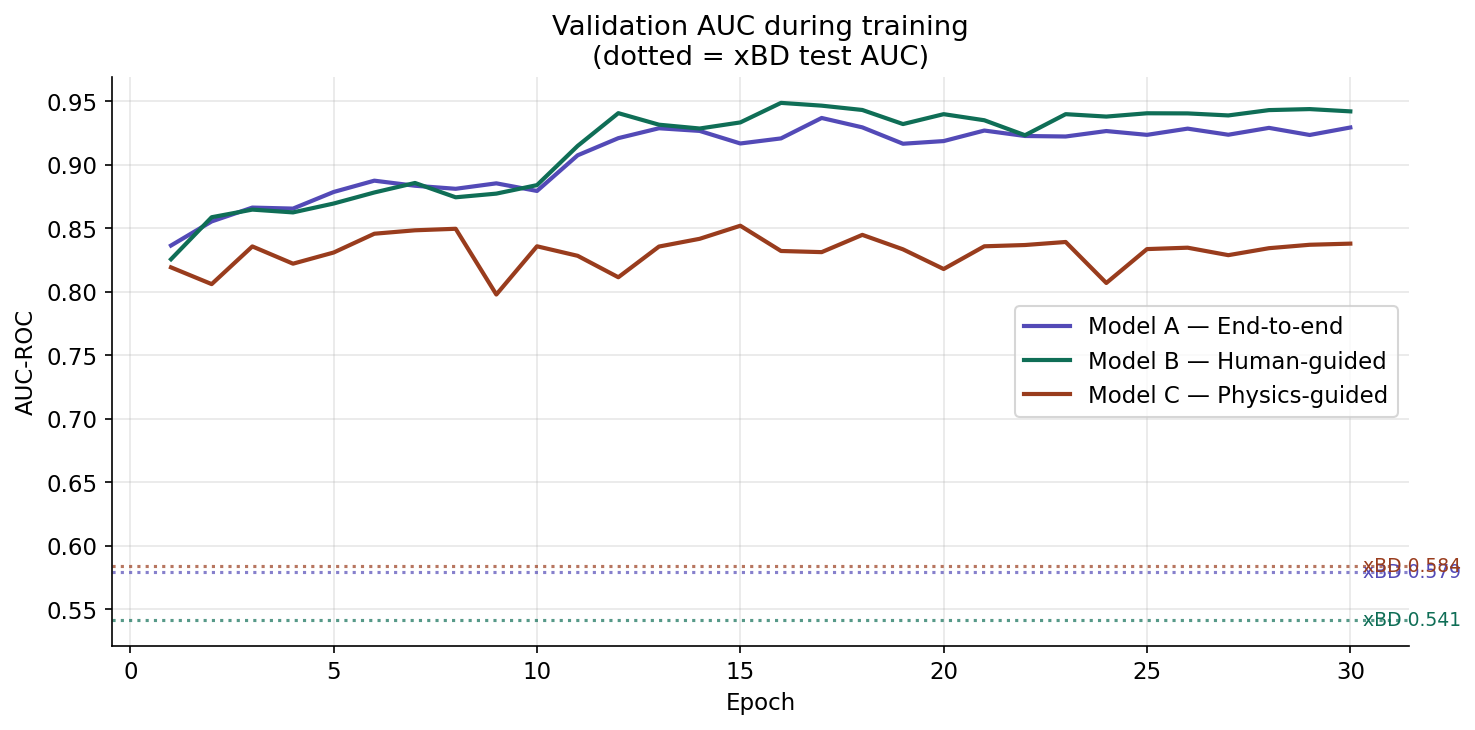

Saved: fig3_val_auc.png


In [6]:
def plot_val_auc(histories, evaluations):
    fig, ax = plt.subplots(figsize=(10, 5))
    for model_id, h in histories.items():
        ax.plot(h["epochs"], h["val_auc"],
                label=LABELS[model_id], color=COLORS[model_id], linewidth=2)
        if model_id in evaluations:
            test_auc = evaluations[model_id]["metrics"]["auc"]
            ax.axhline(y=test_auc, color=COLORS[model_id],
                       linestyle=":", alpha=0.7, linewidth=1.5)
            ax.text(max(h["epochs"]) * 1.01, test_auc,
                    f"xBD {test_auc:.3f}", fontsize=9,
                    color=COLORS[model_id], va="center")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("AUC-ROC")
    ax.set_title("Validation AUC during training\n(dotted = xBD test AUC)")
    ax.legend()
    fig.tight_layout()
    path = FIGURES_DIR / "fig3_val_auc.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if histories:
    plot_val_auc(histories, evaluations)

***5. Figure 4 — Summary table***

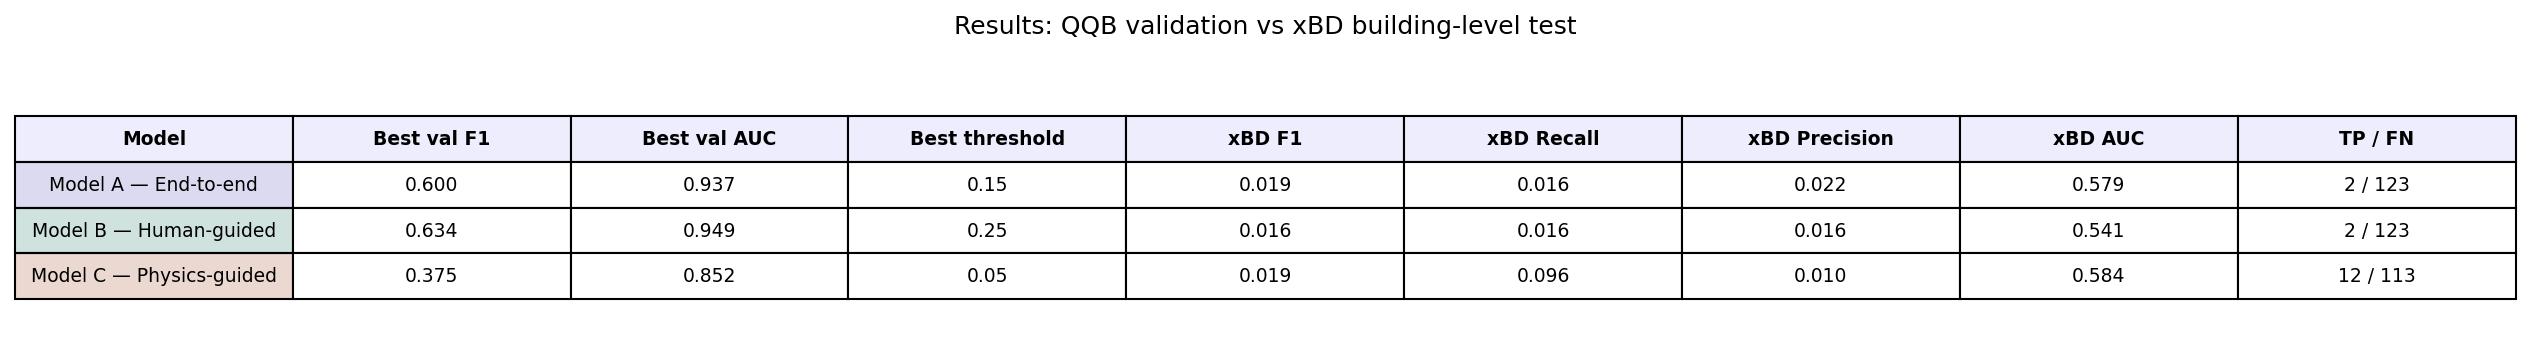

Saved: fig4_summary_table.png


In [7]:
def plot_summary_table(histories, evaluations):
    rows = []
    for model_id in ("A", "B", "C"):
        if model_id not in histories or model_id not in evaluations:
            continue
        h  = histories[model_id]
        ev = evaluations[model_id]
        m  = ev["metrics"]
        rows.append([
            LABELS[model_id],
            f"{max(h['val_f1']):.3f}",
            f"{max(h['val_auc']):.3f}",
            f"{ev.get('best_threshold', 0.5)}",
            f"{m['f1']:.3f}",
            f"{m['recall']:.3f}",
            f"{m['precision']:.3f}",
            f"{m['auc']:.3f}",
            f"{m['tp']} / {m['fn']}",
        ])
    col_labels = [
        "Model", "Best val F1", "Best val AUC",
        "Best threshold",
        "xBD F1", "xBD Recall", "xBD Precision",
        "xBD AUC", "TP / FN",
    ]
    fig, ax = plt.subplots(figsize=(17, 2.5))
    ax.axis("off")
    table = ax.table(cellText=rows, colLabels=col_labels,
                     loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#EEEDFE")
        table[0, j].set_text_props(weight="bold")
    for i, model_id in enumerate(("A", "B", "C"), start=1):
        if i <= len(rows):
            table[i, 0].set_facecolor(COLORS[model_id] + "33")
    ax.set_title("Results: QQB validation vs xBD building-level test",
                 fontsize=12, pad=20)
    fig.tight_layout()
    path = FIGURES_DIR / "fig4_summary_table.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if histories and evaluations:
    plot_summary_table(histories, evaluations)

***6. Figure 5 — Threshold analysis***

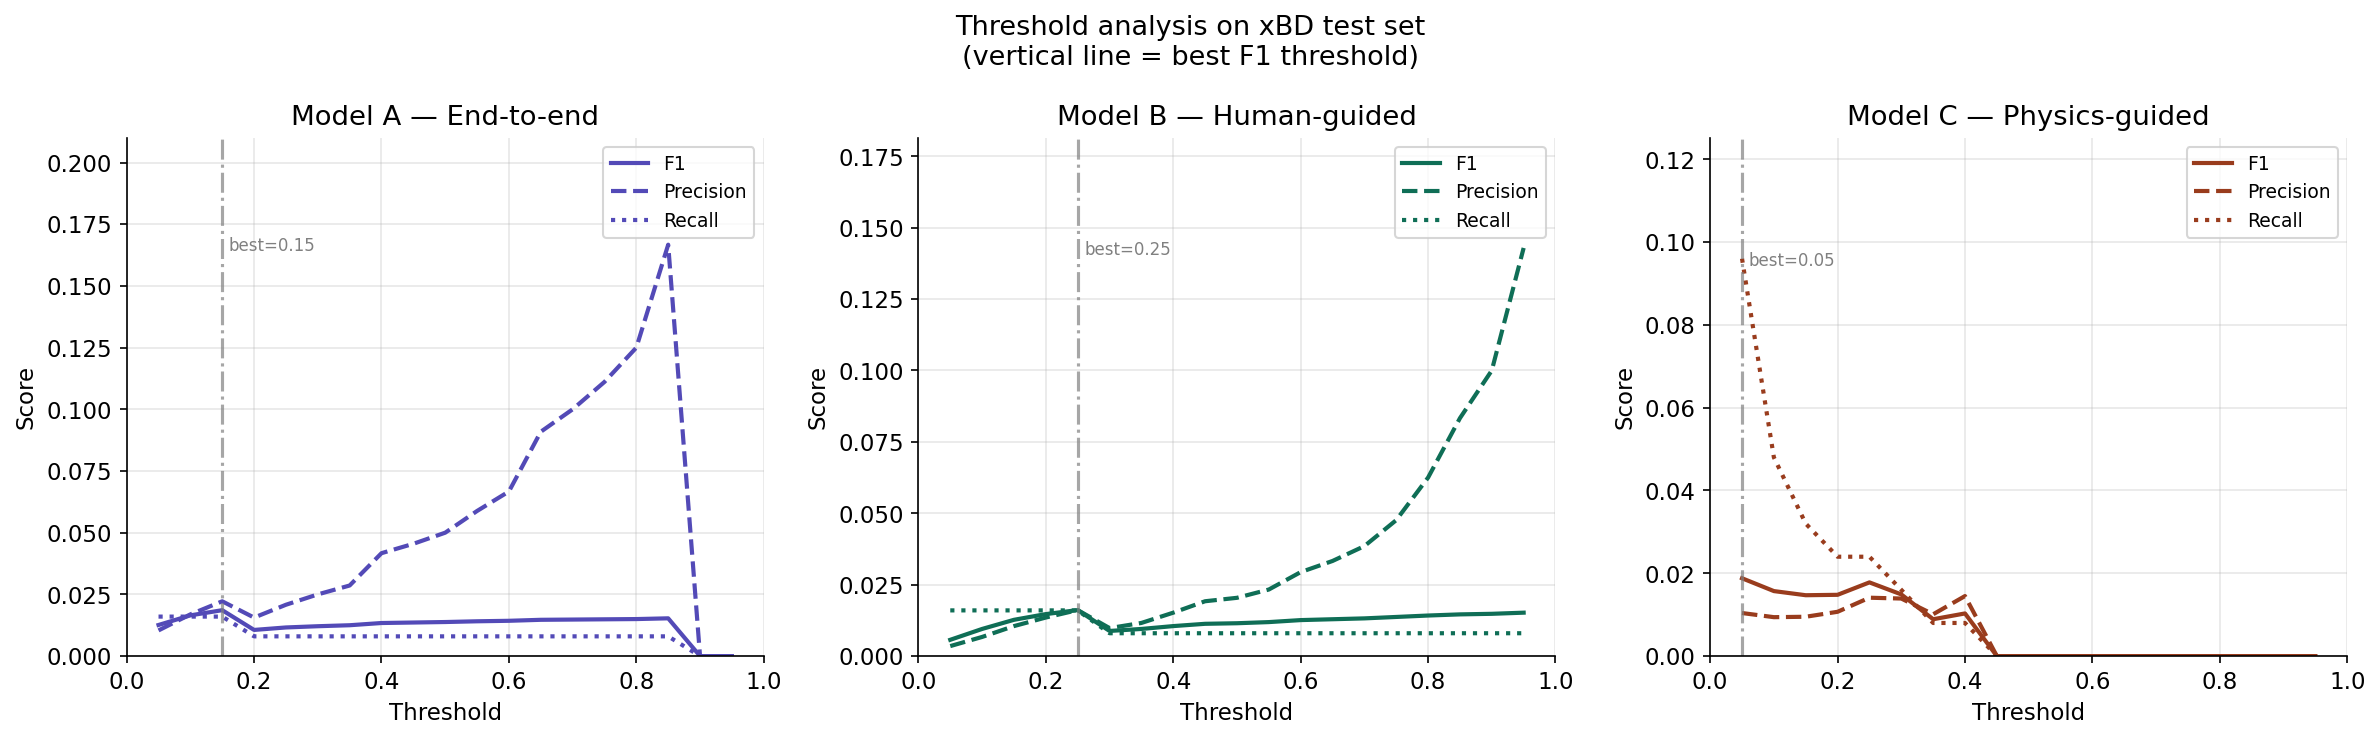

Saved: fig5_threshold_analysis.png


In [8]:
def plot_threshold_analysis(evaluations):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

    for ax, (model_id, ev) in zip(axes, evaluations.items()):
        ta = ev.get("threshold_analysis", [])
        if not ta:
            continue
        thresholds = [t["threshold"] for t in ta]
        f1s        = [t["f1"]        for t in ta]
        precisions = [t["precision"] for t in ta]
        recalls    = [t["recall"]    for t in ta]

        ax.plot(thresholds, f1s,        label="F1",        color=COLORS[model_id], linewidth=2)
        ax.plot(thresholds, precisions, label="Precision", color=COLORS[model_id],
                linewidth=2, linestyle="--")
        ax.plot(thresholds, recalls,    label="Recall",    color=COLORS[model_id],
                linewidth=2, linestyle=":")

        best_t = ev.get("best_threshold", 0.5)
        ax.axvline(x=best_t, color="gray", linestyle="-.", alpha=0.7)
        ax.text(best_t + 0.01, ax.get_ylim()[1] * 0.97,
                f"best={best_t}", fontsize=8, color="gray", va="top")

        ax.set_title(LABELS[model_id])
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Score")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, max(max(f1s), max(precisions), max(recalls)) * 1.2 + 0.01)
        ax.legend(fontsize=9)

    fig.suptitle("Threshold analysis on xBD test set\n"
                 "(vertical line = best F1 threshold)", fontsize=13)
    fig.tight_layout()
    path = FIGURES_DIR / "fig5_threshold_analysis.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if evaluations:
    plot_threshold_analysis(evaluations)

***7. Figure 6 — ROC curves***

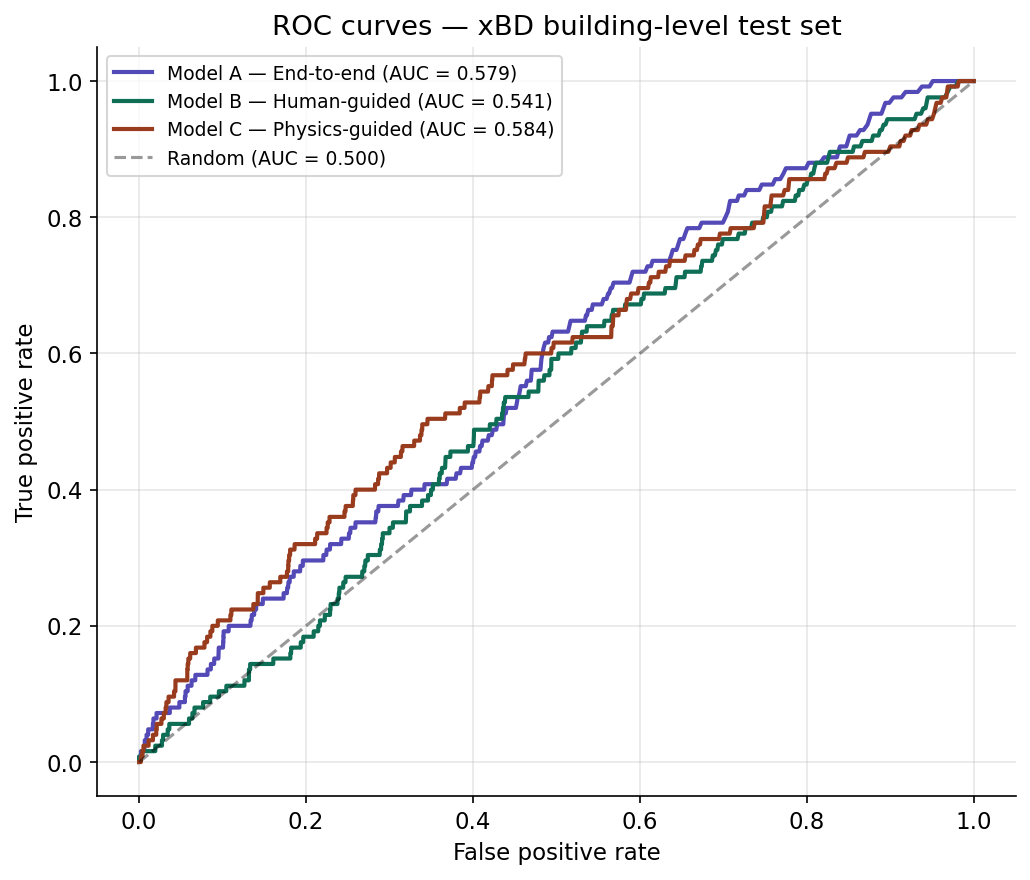

Saved: fig6_roc_curves.png


In [9]:
def plot_roc_curves(evaluations):
    fig, ax = plt.subplots(figsize=(7, 6))
    for model_id, ev in evaluations.items():
        labels = [s["label"] for s in ev["per_sample"]]
        probs  = [s["prob"]  for s in ev["per_sample"]]
        try:
            fpr, tpr, _ = roc_curve(labels, probs)
            roc_auc     = sk_auc(fpr, tpr)
            ax.plot(fpr, tpr, color=COLORS[model_id], linewidth=2,
                    label=f"{LABELS[model_id]} (AUC = {roc_auc:.3f})")
        except Exception as e:
            print(f"  ROC failed for Model {model_id}: {e}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.500)")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC curves \u2014 xBD building-level test set")
    ax.legend(fontsize=9)
    fig.tight_layout()
    path = FIGURES_DIR / "fig6_roc_curves.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if evaluations:
    plot_roc_curves(evaluations)

***8. Figure 7 — Per-severity breakdown***

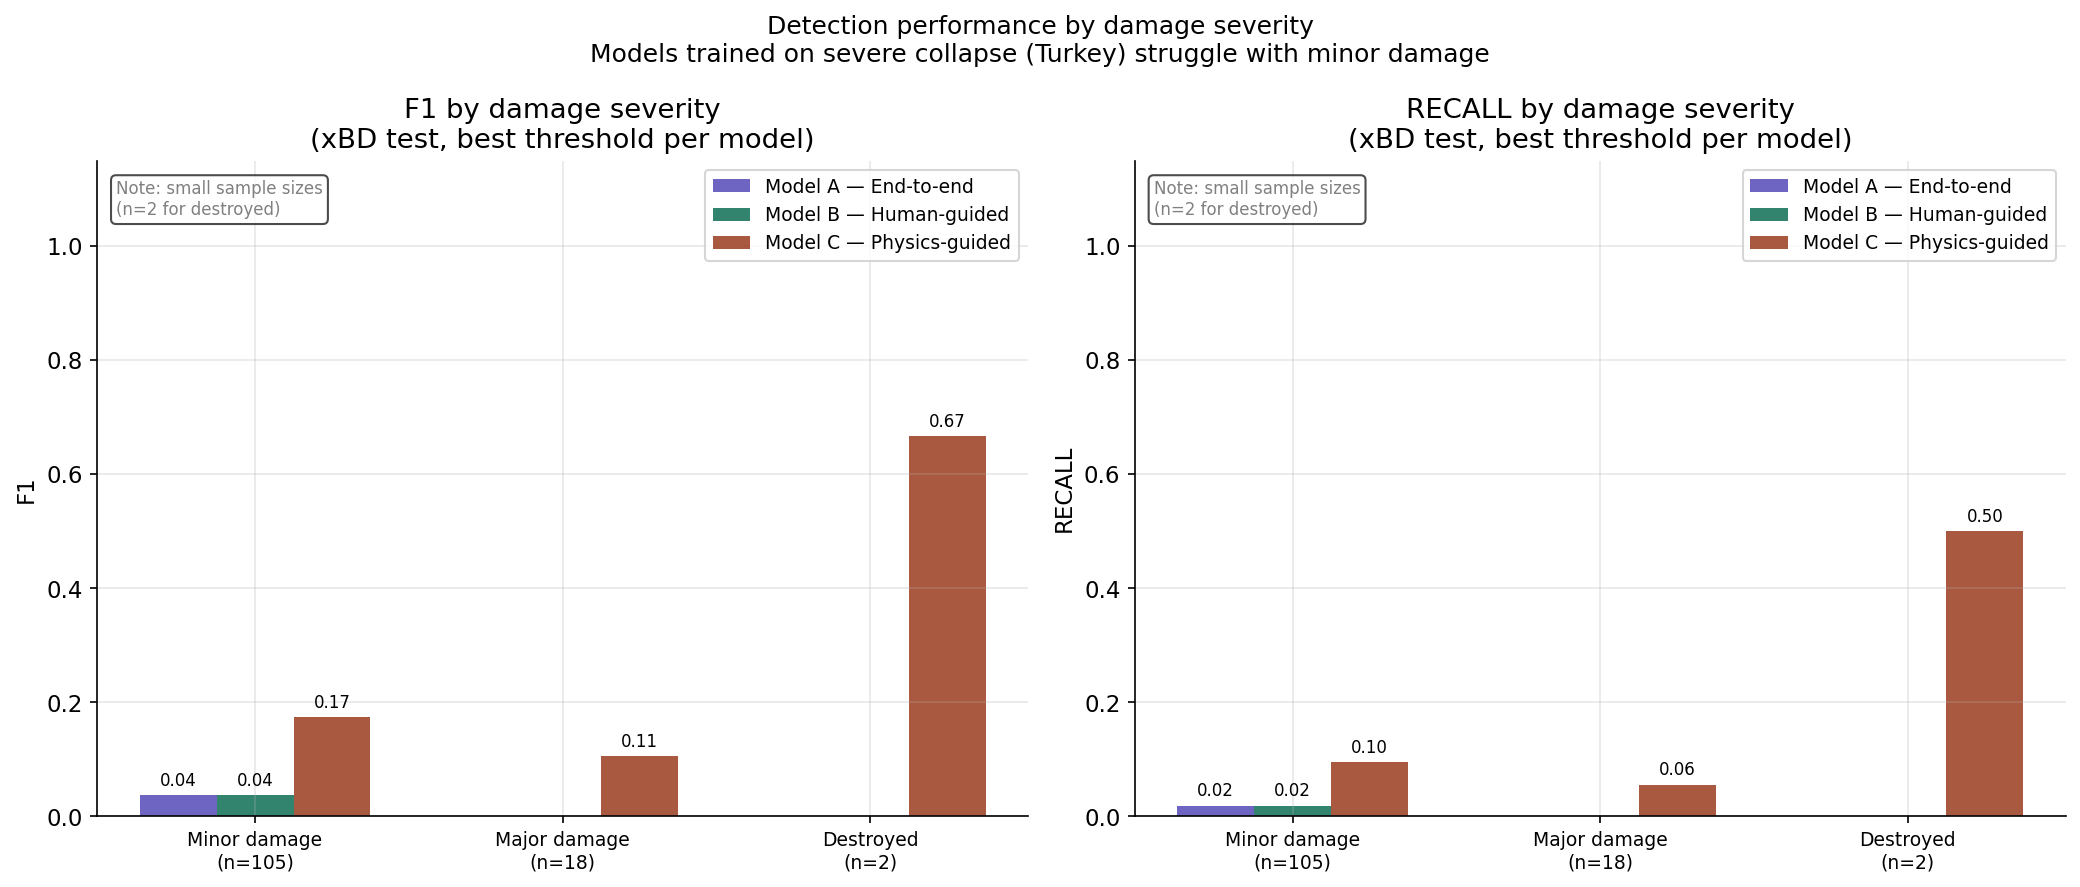

Saved: fig7_severity_breakdown.png


In [10]:
def plot_severity_breakdown(evaluations):
    severities       = ["minor-damage", "major-damage", "destroyed"]
    severity_labels  = ["Minor damage\n(n=105)", "Major damage\n(n=18)", "Destroyed\n(n=2)"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for metric_idx, (metric, ax) in enumerate(zip(["f1", "recall"], axes)):
        x     = np.arange(len(severities))
        width = 0.25

        for i, (model_id, ev) in enumerate(evaluations.items()):
            per_sub = ev.get("per_subtype", {})
            vals    = [
                per_sub.get(sev, {}).get(metric, 0.0)
                for sev in severities
            ]
            bars = ax.bar(
                x + (i - 1) * width, vals, width,
                label=LABELS[model_id],
                color=COLORS[model_id], alpha=0.85,
            )
            for bar, val in zip(bars, vals):
                if val > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=8,
                    )

        ax.set_xticks(x)
        ax.set_xticklabels(severity_labels, fontsize=9)
        ax.set_ylabel(metric.upper())
        ax.set_title(f"{metric.upper()} by damage severity\n(xBD test, best threshold per model)")
        ax.legend(fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.text(0.02, 0.97,
                "Note: small sample sizes\n(n=2 for destroyed)",
                transform=ax.transAxes,
                fontsize=8, va="top", color="gray",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    fig.suptitle("Detection performance by damage severity\n"
                 "Models trained on severe collapse (Turkey) struggle with minor damage",
                 fontsize=12)
    fig.tight_layout()
    path = FIGURES_DIR / "fig7_severity_breakdown.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if evaluations:
    plot_severity_breakdown(evaluations)

***9. Figure 8 — Confusion matrices***

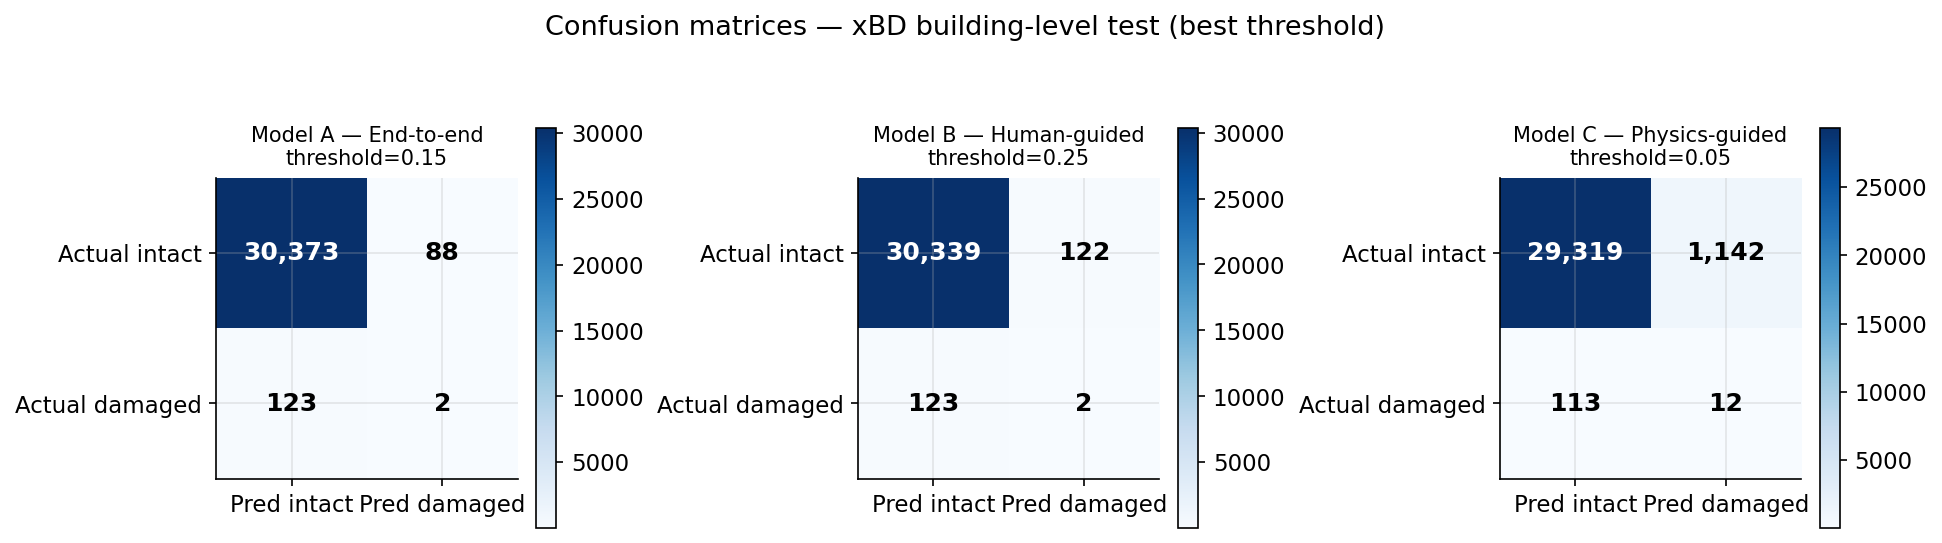

Saved: fig8_confusion_matrices.png


In [11]:
def plot_confusion_matrices(evaluations):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (model_id, ev) in zip(axes, evaluations.items()):
        m   = ev["metrics"]
        cm  = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
        im  = ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Pred intact", "Pred damaged"])
        ax.set_yticklabels(["Actual intact", "Actual damaged"])
        ax.set_title(
            f"{LABELS[model_id]}\nthreshold={ev.get('best_threshold', 0.5)}",
            fontsize=10,
        )
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f"{cm[i,j]:,}",
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black",
                        fontsize=12, fontweight="bold")
        plt.colorbar(im, ax=ax, shrink=0.8)
    fig.suptitle("Confusion matrices \u2014 xBD building-level test (best threshold)",
                 fontsize=13)
    fig.tight_layout()
    path = FIGURES_DIR / "fig8_confusion_matrices.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.name}")


if evaluations:
    plot_confusion_matrices(evaluations)